# Verify allbands loader (sandbox)

Notebook KIỂM TRA khả năng đọc dữ liệu 13-band từ `dataset/allbands/`, **không** training.
Mục tiêu: chắc chắn band index mapping đúng trước khi sang Tầng 2 (spectral indices).

Chạy từng cell theo thứ tự. Nếu cell nào fail hoặc số liệu vô lý, DỪNG và báo lại.

In [1]:
import sys, os
from pathlib import Path

# Cho phép import src.* khi chạy notebook từ thư mục notebooks/
ROOT = Path.cwd()
if (ROOT / 'src').exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / 'src').exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise RuntimeError(f'Khong tim thay thu muc src/ tu {ROOT}')
sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT =', PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.data.eurosat_dataset import (
    read_patch, compute_indices,
    ALL_BANDS, BAND_TO_IDX, INDEX_DEFS, RGB_BANDS,
)
print('ALL_BANDS =', ALL_BANDS)

PROJECT_ROOT = d:\FPT\kỳ 5\DPL302M\project
ALL_BANDS = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A']


## 1. Load 1 anh tu AnnualCrop (file dau tien)

In [2]:
ALLBANDS_DIR = PROJECT_ROOT / 'dataset' / 'allbands'
ac_dir = ALLBANDS_DIR / 'AnnualCrop'
files = sorted(p for p in os.listdir(ac_dir) if p.endswith('.tif'))
sample_path = ac_dir / files[0]
print('File mau:', sample_path.name)

arr = read_patch(str(sample_path))   # (13, H, W) float32 theo thu tu ALL_BANDS
print('Shape           :', arr.shape)
print('So channels     :', arr.shape[0])
print('Dtype           :', arr.dtype, '(ky vong float32)')

File mau: AnnualCrop_1.tif
Shape           : (13, 64, 64)
So channels     : 13
Dtype           : float32 (ky vong float32)


## 2. Min/Max/Mean moi channel (kem ten band va resolution Sentinel-2)

In [3]:
# Resolution gốc cua tung band Sentinel-2 (m). Du lieu da resample ve 64x64 luoi 10m.
BAND_RES = {
    'B01': 60, 'B02': 10, 'B03': 10, 'B04': 10, 'B05': 20, 'B06': 20, 'B07': 20,
    'B08': 10, 'B09': 60, 'B10': 60, 'B11': 20, 'B12': 20, 'B8A': 20,
}
print(f"{'idx':>3} {'band':>5} {'res(m)':>6} {'min':>10} {'max':>10} {'mean':>10}")
for i, b in enumerate(ALL_BANDS):
    ch = arr[i]
    print(f'{i:>3} {b:>5} {BAND_RES[b]:>6} {ch.min():>10.2f} {ch.max():>10.2f} {ch.mean():>10.2f}')

idx  band res(m)        min        max       mean
  0   B01     60    1235.00    1420.00    1323.20
  1   B02     10    1002.00    1534.00    1124.51
  2   B03     10     905.00    1664.00    1044.73
  3   B04     10     893.00    2297.00    1169.28
  4   B05     20    1034.00    2128.00    1291.63
  5   B06     20    1120.00    2376.00    1553.75
  6   B07     20    1238.00    2689.00    1765.67
  7   B08     10    1186.00    2977.00    1748.96
  8   B09     60     353.00     631.00     484.06
  9   B10     60       9.00      14.00      11.57
 10   B11     20    2248.00    3490.00    2715.40
 11   B12     20    1236.00    2537.00    1980.89
 12   B8A     20    1404.00    3108.00    2030.55


## 3. Verify band index mapping (CUC KY quan trong)

Sai index -> NDBI/NDMI tinh sai ma khong bao loi -> hong toan bo Tang 2.

In [4]:
print('Thu tu band loader tra ve:')
for i, b in enumerate(ALL_BANDS):
    print(f'  idx {i:>2} -> {b}')

print('\nKiem tra cac band quan trong:')
expect = {'B02': 1, 'B03': 2, 'B04': 3, 'B08': 7, 'B11': 10, 'B12': 11, 'B8A': 12}
all_ok = True
for b, idx in expect.items():
    got = BAND_TO_IDX[b]
    ok = got == idx
    all_ok &= ok
    print(f'  {b}: BAND_TO_IDX={got}, ky vong={idx}  {"OK" if ok else "!!! SAI"}')

# Diem mau chot: B8A o CUOI (idx 12), B11 o idx 10 (KHONG phai 11).
assert BAND_TO_IDX['B8A'] == 12, 'B8A phai o index 12 (cuoi)'
assert BAND_TO_IDX['B11'] == 10, 'B11 phai o index 10'
print('\n=> Band mapping', 'DUNG' if all_ok else 'CO LOI', '(B8A cuoi, B11 idx 10)')

Thu tu band loader tra ve:
  idx  0 -> B01
  idx  1 -> B02
  idx  2 -> B03
  idx  3 -> B04
  idx  4 -> B05
  idx  5 -> B06
  idx  6 -> B07
  idx  7 -> B08
  idx  8 -> B09
  idx  9 -> B10
  idx 10 -> B11
  idx 11 -> B12
  idx 12 -> B8A

Kiem tra cac band quan trong:
  B02: BAND_TO_IDX=1, ky vong=1  OK
  B03: BAND_TO_IDX=2, ky vong=2  OK
  B04: BAND_TO_IDX=3, ky vong=3  OK
  B08: BAND_TO_IDX=7, ky vong=7  OK
  B11: BAND_TO_IDX=10, ky vong=10  OK
  B12: BAND_TO_IDX=11, ky vong=11  OK
  B8A: BAND_TO_IDX=12, ky vong=12  OK

=> Band mapping DUNG (B8A cuoi, B11 idx 10)


## 4. Visualize 3 cau hinh: True color RGB / False color CI / B11 SWIR

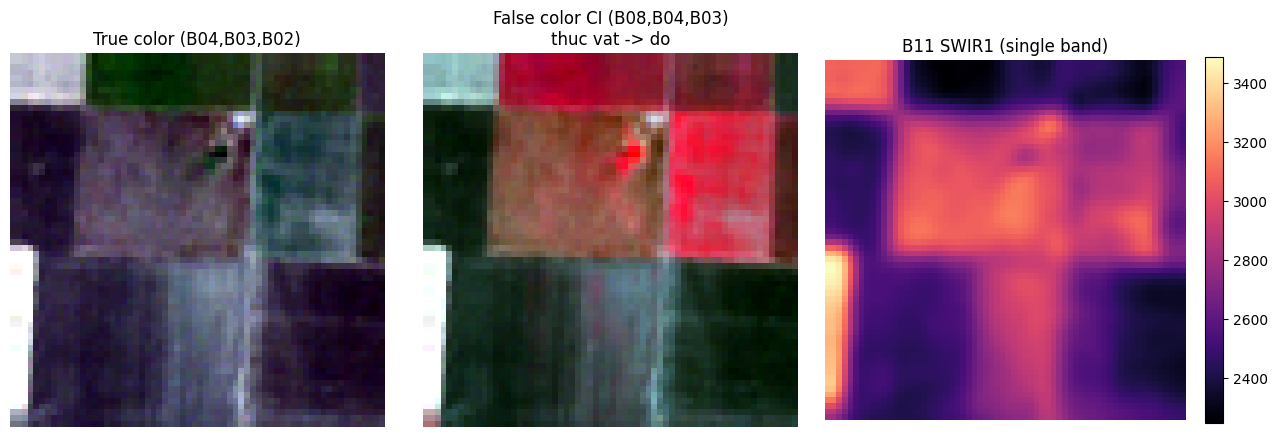

In [5]:
def stretch(rgb, p=2):
    """Percentile stretch ve [0,1] de hien thi (khong dung cho training)."""
    out = np.empty_like(rgb, dtype=np.float32)
    for c in range(rgb.shape[-1]):
        ch = rgb[..., c]
        lo, hi = np.percentile(ch, p), np.percentile(ch, 100 - p)
        out[..., c] = np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1)
    return out

def band(name):
    return arr[BAND_TO_IDX[name]]

true_color = np.stack([band('B04'), band('B03'), band('B02')], axis=-1)   # R,G,B
false_ci   = np.stack([band('B08'), band('B04'), band('B03')], axis=-1)   # NIR,R,G

fig, ax = plt.subplots(1, 3, figsize=(13, 4.3))
ax[0].imshow(stretch(true_color)); ax[0].set_title('True color (B04,B03,B02)')
ax[1].imshow(stretch(false_ci));   ax[1].set_title('False color CI (B08,B04,B03)\nthuc vat -> do')
im = ax[2].imshow(band('B11'), cmap='magma'); ax[2].set_title('B11 SWIR1 (single band)')
plt.colorbar(im, ax=ax[2], fraction=0.046)
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 5. Pipeline upsample 20m/60m -> 10m (bilinear)

Du lieu EuroSATallBands da luu MOI band o 64x64 (luoi 10m) nen day la no-op.
Cell nay XAC NHAN dieu do va minh hoa buoc upsample se chay ra sao neu can.

In [6]:
print('Shape moi band truoc upsample:')
for i, b in enumerate(ALL_BANDS):
    print(f'  {b:>5}: {arr[i].shape}')

shapes = {arr[i].shape for i in range(arr.shape[0])}
print('\nTap hop shape cac band:', shapes)
assert shapes == {(64, 64)}, 'Co band khong phai 64x64 -> can upsample that su!'
print('=> Tat ca band deu 64x64 san. Upsample la NO-OP.')

# Minh hoa buoc bilinear (vao 64x64 -> ra 64x64, khong doi gi).
t = torch.from_numpy(arr).unsqueeze(0)                       # (1,13,64,64)
up = F.interpolate(t, size=(64, 64), mode='bilinear', align_corners=False)
print('Shape sau interpolate:', tuple(up.shape[1:]))
print('Sai khac so voi goc (max abs):', (up.squeeze(0) - torch.from_numpy(arr)).abs().max().item())

Shape moi band truoc upsample:
    B01: (64, 64)
    B02: (64, 64)
    B03: (64, 64)
    B04: (64, 64)
    B05: (64, 64)
    B06: (64, 64)
    B07: (64, 64)
    B08: (64, 64)
    B09: (64, 64)
    B10: (64, 64)
    B11: (64, 64)
    B12: (64, 64)
    B8A: (64, 64)

Tap hop shape cac band: {(64, 64)}
=> Tat ca band deu 64x64 san. Upsample la NO-OP.
Shape sau interpolate: (13, 64, 64)
Sai khac so voi goc (max abs): 0.0


## 6. Test tinh NDVI tren 1 anh

NDVI = (B08 - B04) / (B08 + B04 + 1e-8). Vung thuc vat ~ 0.4-0.8, range tong the [-1,1].

NDVI  min=0.0797  max=0.4913  mean=0.1888
Sai khac voi compute_indices (max abs): 0.0


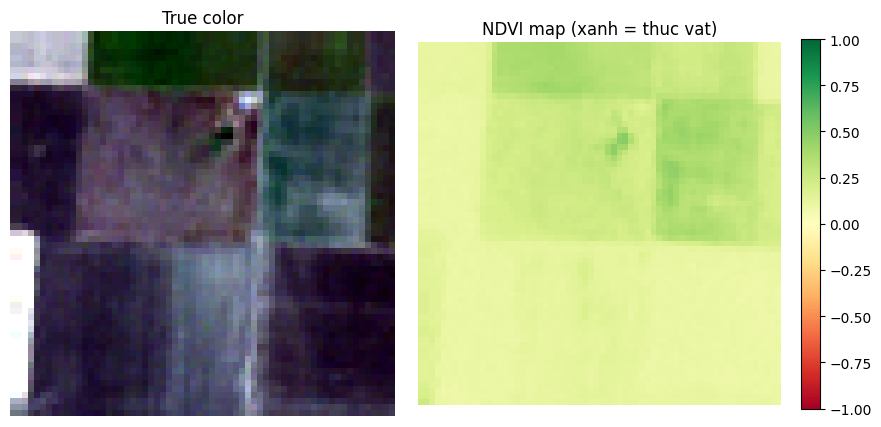

In [7]:
b08 = band('B08'); b04 = band('B04')
ndvi = (b08 - b04) / (b08 + b04 + 1e-8)
print(f'NDVI  min={ndvi.min():.4f}  max={ndvi.max():.4f}  mean={ndvi.mean():.4f}')
assert -1.0 <= ndvi.min() and ndvi.max() <= 1.0, 'NDVI ngoai [-1,1]!'

# Doi chieu voi compute_indices() cua loader (phai khop tuyet doi).
ndvi_loader = compute_indices(arr, ['NDVI'])[0]
print('Sai khac voi compute_indices (max abs):', np.abs(ndvi - ndvi_loader).max())

fig, ax = plt.subplots(1, 2, figsize=(9, 4.3))
ax[0].imshow(stretch(true_color)); ax[0].set_title('True color'); ax[0].axis('off')
im = ax[1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax[1].set_title('NDVI map (xanh = thuc vat)'); ax[1].axis('off')
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Ket luan

Neu tat ca cell tren chay sach (band mapping DUNG, B8A idx 12 / B11 idx 10, NDVI trong [-1,1] va khop loader, moi band 64x64):
**loader san sang cho T1-R2 (13 bands) va Tang 2 (spectral indices).**